# Assessing the Skill of the Climatological Ensemble with the Continuous Ranked Probability Score (CRPS)
Version 20 December 2022, Selina Kiefer

### Input: csv-files
ensemble of continuous timeseries of ground truth temperature for a winter (e.g. climatological ensemble) in csv-format, continuous timeseries of ground truth temperature in csv-format
### Output: csv-file, png-files
continuous timeseries of daily CRPS values in csv-format and plotted in png-format as well as the prediction of the climatological ensemble plotted together with the ground truth in png-format

#### Set the paths' to the defined functions and configuration file and set its name

In [1]:
# Set the path to the defined functions.
PATH_defined_functions = './Defined_Functions/'

In [2]:
# Set the path and name of the configuration file.
PATH_configurations = './Configuration_Files/'
ifile_configurations = 'Configurations_Skill_Assessment_Climatological_Ensemble_with_CRPS.yaml'

#### Import the necessary python packages and functions
Nothing needs to be changed here.

In [3]:
# Import the necessary python packages.
import yaml
import calendar
import numpy as np
import calendar
from datetime import datetime, timedelta
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import properscoring as ps

In [4]:
# Import the necessary defined functions.
import sys
sys.path.insert(1, PATH_defined_functions)
from read_in_csv_data import *
from truncate_data_by_date import*
from create_auxiliary_date import *

#### Read in the configuration file and the data specified in it

In [5]:
# Read in the configuration file (nothing needs to be changed here).
with open(PATH_configurations+ifile_configurations) as f:
    config = yaml.safe_load(f)

In [6]:
# Read in the climatological_ensemble and remove any unnamed columns as well as the index column (nothing 
# needs to be changed here).
df_climatological_ensemble = read_in_csv_data(config['PATH_climatological_ensemble'], config['ifile_climatological_ensemble'])
df_climatological_ensemble = df_climatological_ensemble.loc[:, ~df_climatological_ensemble.columns.str.contains('^Unnamed')]
df_climatological_ensemble = df_climatological_ensemble.drop(['index'], axis =1 )

In [7]:
# Set the name of the columns containing the time and the variables of the climatological_ensemble.
time_column_name_climatological_ensemble = df_climatological_ensemble.columns[0]
var_column_name_climatological_ensemble = df_climatological_ensemble.columns[1:]

In [8]:
# Check that everything is selected correctly (nothing needs to be changed here).
print('Names of ensemble members of the climatological ensemble: ')
print(var_column_name_climatological_ensemble)
print('Name of the column containing the time: ')
print(time_column_name_climatological_ensemble)
print('Dataframe containing the climatological ensemble: ')
df_climatological_ensemble.head()

Names of climatological_ensemble done by the ML model: 
Index(['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020'],
      dtype='object')
Name of the column containing the time: 
auxiliary_date
Dataframe containing the climatological_ensemble: 


,auxiliary_date,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,2003-11-01,282.51,278.98,280.39,275.16,275.63,280.06,277.41,280.78,279.55,...,282.00,278.98,280.84,282.76,280.46,280.46,280.34,281.78,277.90,NaN
1,2003-11-02,281.84,280.87,280.63,275.29,276.43,279.84,278.78,279.86,278.94,...,281.30,279.46,282.45,282.92,279.36,278.85,281.44,282.01,281.65,NaN
2,2003-11-03,282.60,280.65,280.82,276.01,276.35,279.88,278.86,282.78,278.61,...,281.65,280.08,281.46,282.97,278.90,276.33,280.58,280.88,282.47,NaN
3,2003-11-04,280.76,281.19,279.83,278.07,275.80,279.55,278.59,282.28,279.40,...,282.11,280.71,280.43,282.49,280.06,276.57,280.81,281.46,281.81,NaN
4,2003-11-05,279.26,280.21,280.37,280.32,275.37,279.26,279.08,281.05,279.47,...,282.65,279.19,279.08,281.43,281.22,278.59,280.56,282.85,280.10,NaN


In [9]:
# Read in the ground truth and remove any unnamed columns as well as the index column (nothing 
# needs to be changed here).
df_ground_truth = read_in_csv_data(config['PATH_ground_truth'], config['ifile_ground_truth'])
df_ground_truth = df_ground_truth.loc[:, ~df_ground_truth.columns.str.contains('^Unnamed')]
df_ground_truth = df_ground_truth.drop(['index'], axis =1 )

In [10]:
# Set the name of the columns containing the time and the variables of the ground truth.
time_column_name_ground_truth = df_ground_truth.columns[0]
var_column_name_ground_truth = df_ground_truth.columns[1]

In [11]:
# Check that everything is selected correctly (nothing needs to be changed here).
print('Ground truth to compare the climatological ensemble with: ')
print(var_column_name_ground_truth)
print('Name of the column containing the time: ')
print(time_column_name_ground_truth)
print('Dataframe containing the ground truth: ')
df_ground_truth.head()

Ground truth to compare the climatological_ensemble with: 
tg
Name of the column containing the time: 
time
Dataframe containing the ground truth: 


,time,tg
0,1950-01-29,266.20
1,1950-01-30,265.80
2,1950-01-31,267.56
3,1950-02-01,269.39
4,1950-02-02,269.77


#### Prepare the climatological ensemble and the ground truth for the skill assessment 
From here on, nothing needs to be changed.

In [12]:
# A list with all start years of the winters in the evaluation period is created. 
start_years_of_winter = np.arange(config['start_year_of_first_winter'], config['start_year_of_last_winter']+1)

In [13]:
# In a next step, two different dataframes are created with the climatological ensemble. One for 
# regular years and one for leap years. Therefore, the index of the original dataframe is set 
# to the time and the index of the 29 February is determined. Then, a new  dataframe without 
# the 29 February is created for regular years. The original dataframe is used for leap years.
df_climatological_ensemble[time_column_name_climatological_ensemble]=pd.to_datetime(df_climatological_ensemble[time_column_name_climatological_ensemble])
df_climatological_ensemble = df_climatological_ensemble.set_index(time_column_name_climatological_ensemble)
index_of_february_29 = df_climatological_ensemble[((df_climatological_ensemble.index.month == 2) & (df_climatological_ensemble.index.day == 29))].index
df_climatological_ensemble_without_29_feb = df_climatological_ensemble.drop(index_of_february_29)
df_climatological_ensemble = df_climatological_ensemble.reset_index()
df_climatological_ensemble_without_29_feb = df_climatological_ensemble_without_29_feb.reset_index()

In [14]:
# Now, the climatological ensemble of each year is extracted and saved to a list. The same is
# done for the ground truth. The respective forecast dates of each year are also saved to a 
# list. 
climatological_ensemble = []
ground_truth = []
forecast_dates = []

for start_year_of_winter in start_years_of_winter:
    
    start_winter = datetime(start_year_of_winter, config['start_month_winter'], config['start_day_winter'])
    end_winter = datetime(start_year_of_winter+1, config['end_month_winter'], config['end_day_winter'])

    df_ground_truth_respective_winter = truncate_data_by_date(df_ground_truth, time_column_name_ground_truth, start_winter.strftime('%Y_%m_%d'), end_winter.strftime('%Y_%m_%d')) 
   
    if calendar.isleap(start_year_of_winter+1):
        df_climatological_ensemble_respective_winter = df_climatological_ensemble   
    else:
        df_climatological_ensemble_respective_winter = df_climatological_ensemble_without_29_feb
    
    climatological_ensemble_respective_winter = df_climatological_ensemble_respective_winter.drop([time_column_name_climatological_ensemble], axis=1)
    climatological_ensemble_respective_winter = np.array(np.squeeze(climatological_ensemble_respective_winter))
 
    climatological_ensemble.append(climatological_ensemble_respective_winter)
    
    ground_truth.append(df_ground_truth_respective_winter[var_column_name_ground_truth])
    forecast_dates.append(pd.to_datetime(df_ground_truth_respective_winter[time_column_name_ground_truth]))

#### Calculation of the CRPS between the ground truth and the climatological ensemble

In [15]:
# Now, the CRPS between the ground truth data and the QRF forecasts is computed
# (ps.crps_ensemble), converted into a dataframe and written into a list. Additionally, a 
# continuous list of all forecast dates is created.
crps = []
crps_winterwise = []
forecast_time = []

for l in range(len(start_years_of_winter)):
       
    for_crps = ps.crps_ensemble(ground_truth[l], climatological_ensemble[l]) 
    df_crps = pd.DataFrame(for_crps)
    crps.extend(np.array(df_crps))
    crps_winterwise.append(np.array(df_crps))
    forecast_time.extend(forecast_dates[l])

In [16]:
# The CRPS and the respective forecast dates are saved in a new dataframe. The CRPS values
# are rounded for a nicer representation.
df_skill_measure_crps = pd.DataFrame()
crps = np.round(crps, decimals=2)

df_skill_measure_crps['time'] = forecast_time
df_skill_measure_crps['CRPS'] = crps

#### Save the CRPS in csv-format

In [17]:
# Now, the pandas dataframe containing the CRPS values is saved in csv format. 
df_skill_measure_crps.to_csv(config['PATH_statistics']+config['model_name']+'_CRPS_ground_truth_'+config['ground_truth']+'_'+config['location_ground_truth']+'_input_'+config['input_data']+'_'+config['location_input']+'_'+str(config['start_year_of_first_winter'])+'_'+str(config['start_year_of_last_winter']+1)+'.csv')

#### Visualizing the predictions of the climatological ensemble together with the ground truth and the CRPS for a plausibility check

In [18]:
# Before plotting, the information about the input data which should be shown in the plot title
# is converted to a nice-looking string by creating the line-breaks set in the configuration 
# file.
str_input_info_for_plot_titles = config['input_data_title']
str_input_info_for_plot_titles = str_input_info_for_plot_titles.replace('|', '\n')

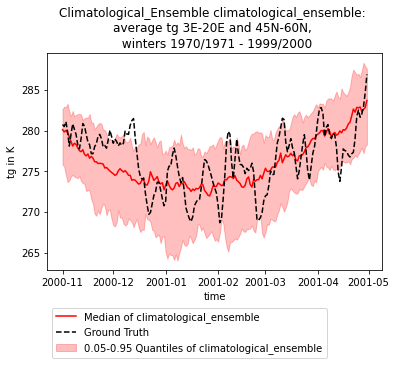

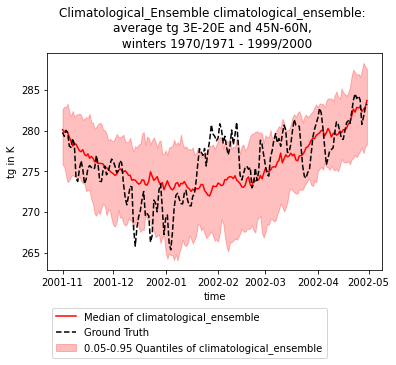

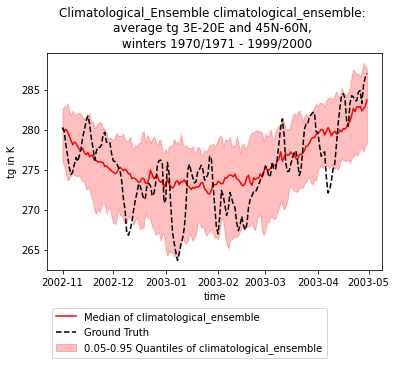

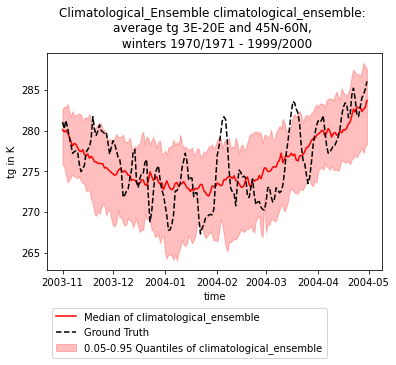

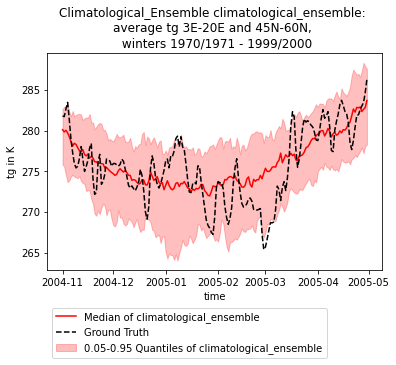

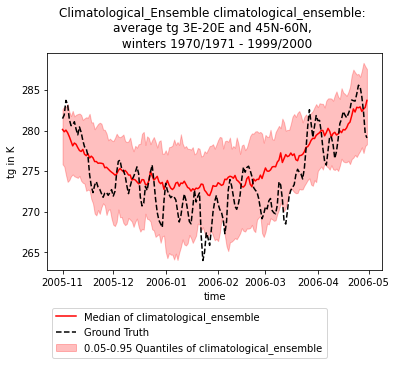

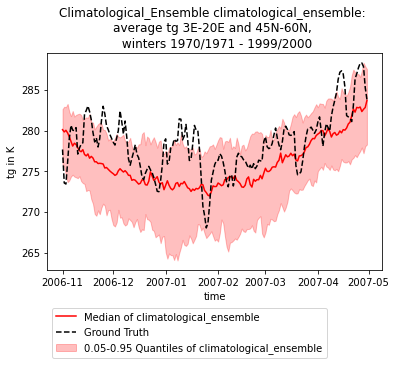

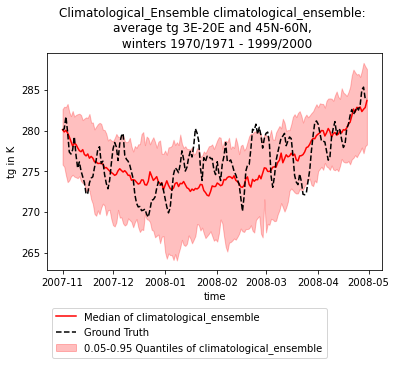

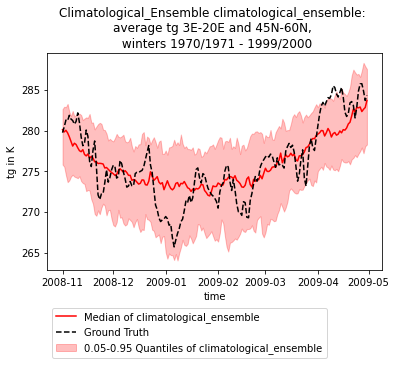

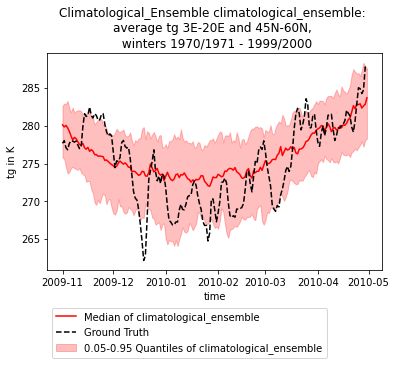

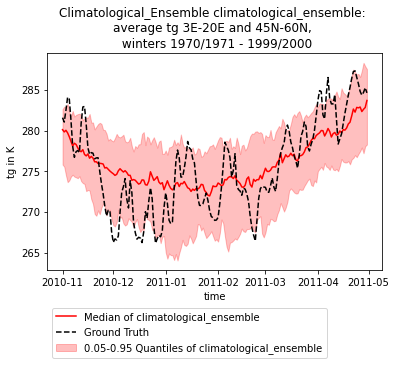

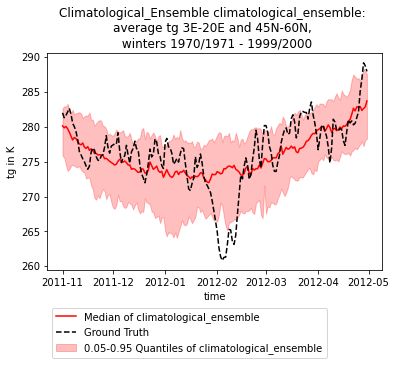

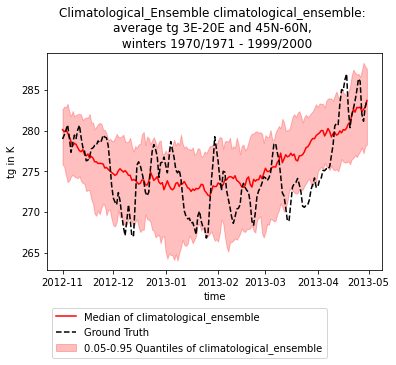

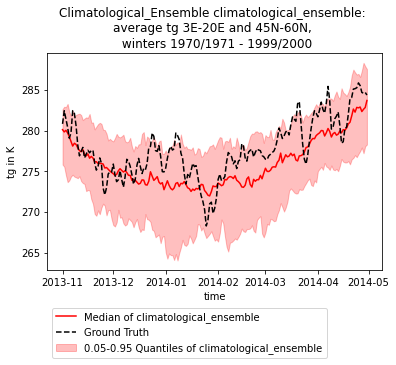

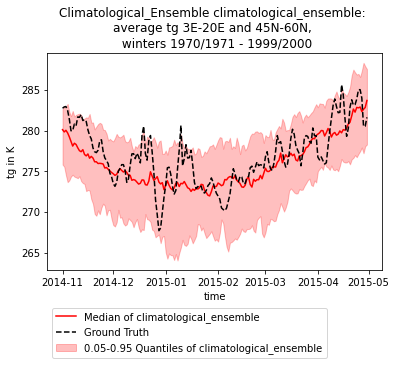

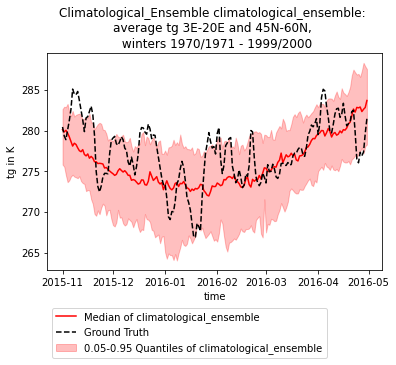

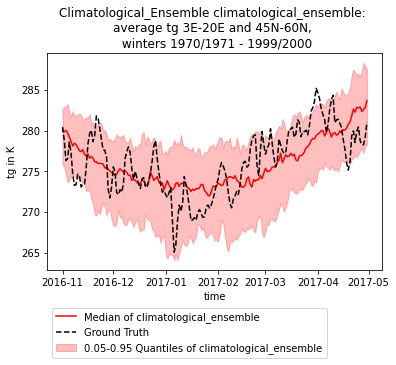

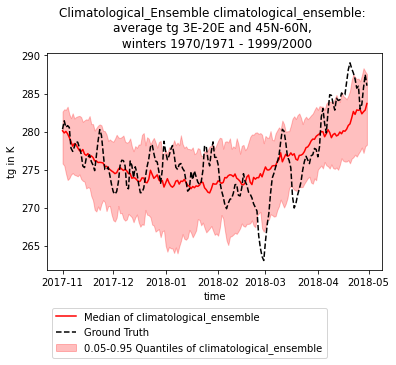

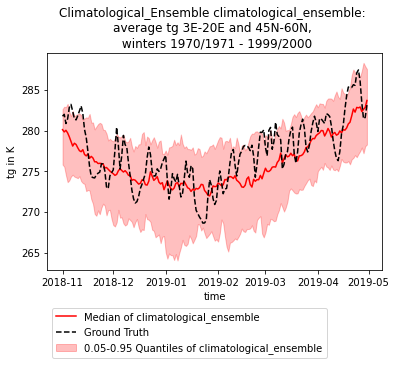

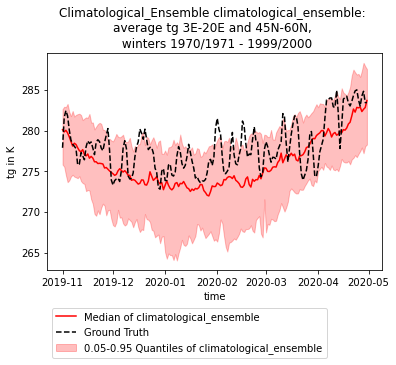

In [19]:
# For illustration purposes, the median and two in the configuration file defined percentiles of
# the climatological_ensemble are plotted together with the ground truth. This gives a first impression
# about the models' forecast skill.
for k in range(len(start_years_of_winter)):
    fig = plt.subplots()
    plt.plot(forecast_dates[k], np.nanmedian(climatological_ensemble[k], axis=1), color='r', label='Median of climatological_ensemble')
    plt.fill_between(x=forecast_dates[k], y1=np.nanpercentile(climatological_ensemble[k], config['upper_quantile']*100, axis=1), y2=np.nanpercentile(climatological_ensemble[k], config['lower_quantile']*100, axis=1), color='r', alpha=0.25, label=(str(config['lower_quantile'])+'-'+str(config['upper_quantile'])+' Quantiles of climatological_ensemble'))
    plt.plot(forecast_dates[k], np.array(np.squeeze(ground_truth[k])), color='k', linestyle='--', label='Ground Truth')
    plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left')
    plt.xlabel(time_column_name_ground_truth)
    plt.ylabel(var_column_name_ground_truth+' in '+config['unit_of_ground_truth_and_climatological_ensemble'])
    plt.title(config['model_name']+' climatological_ensemble: \n'+str_input_info_for_plot_titles)
    plt.savefig(config['PATH_plots']+config['model_name']+'_'+config['ground_truth']+'_'+config['location_ground_truth']+'_input_'+config['input_data']+'_'+config['location_input']+'_'+str(start_years_of_winter[k])+'_'+str(start_years_of_winter[k]+1)+'.png', bbox_inches='tight')

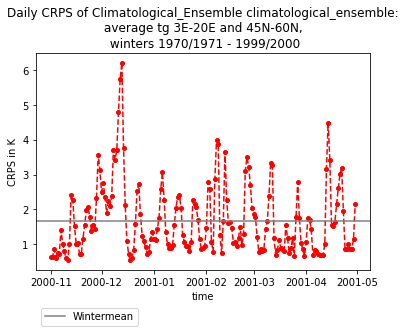

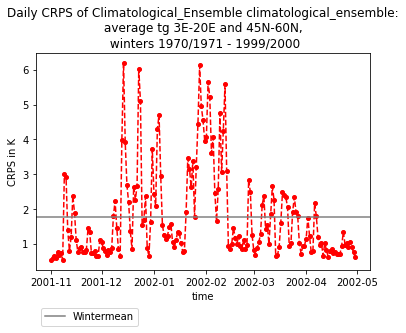

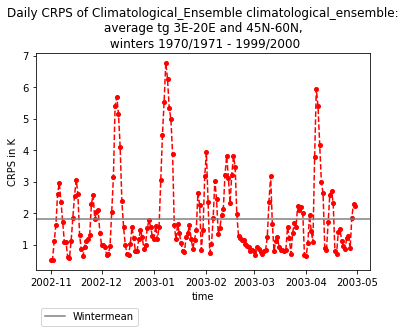

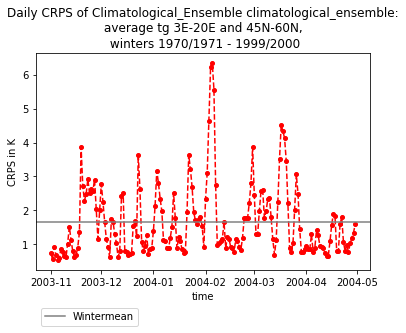

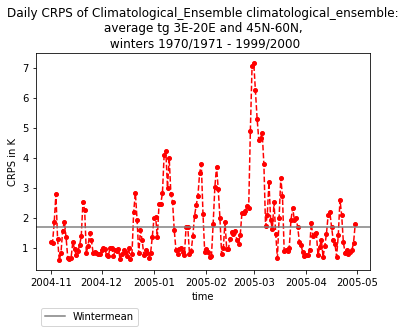

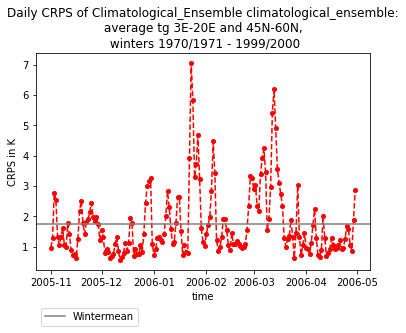

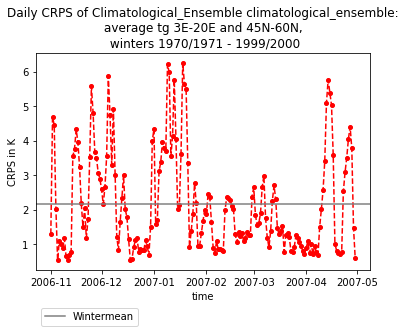

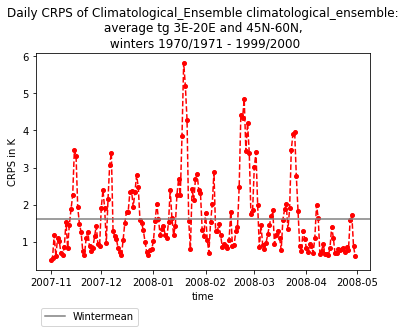

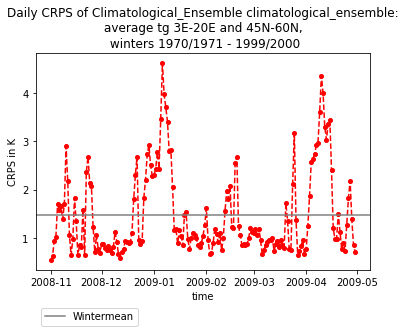

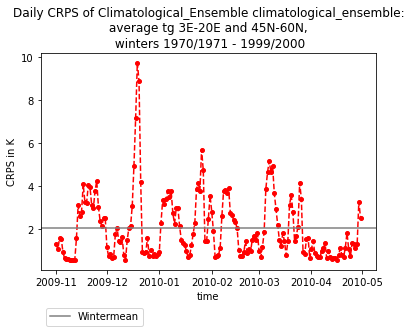

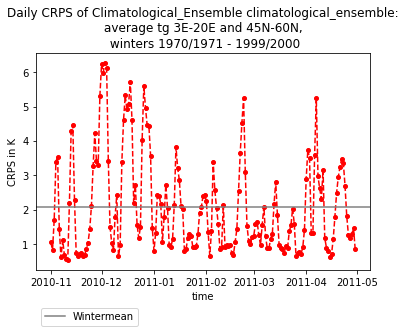

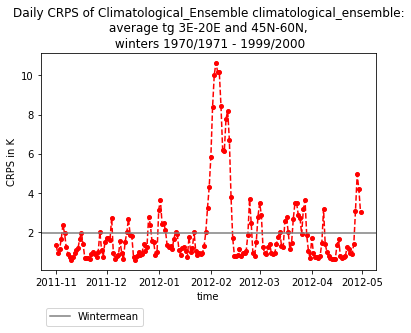

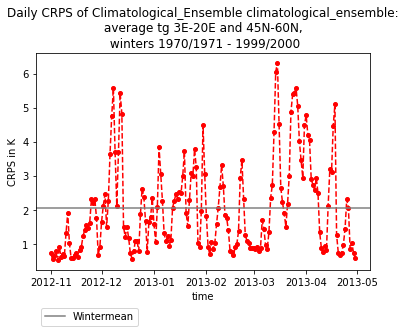

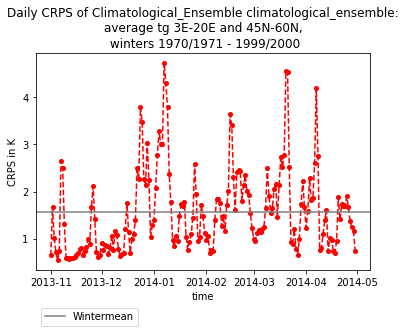

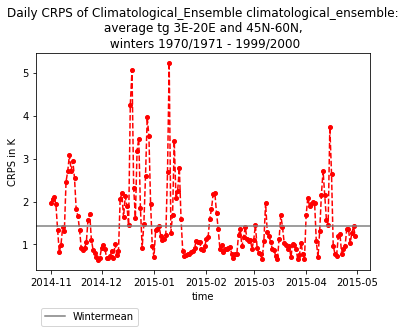

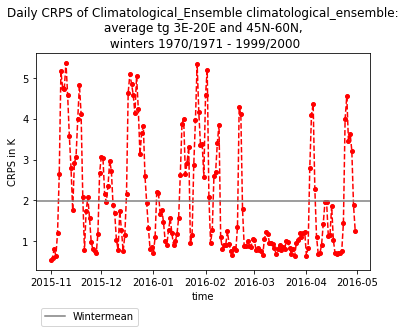

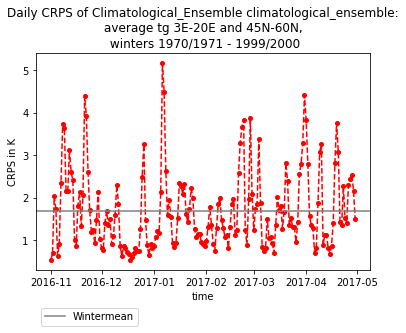

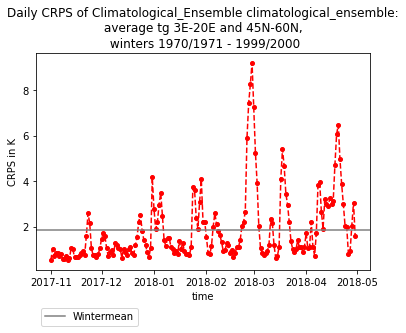

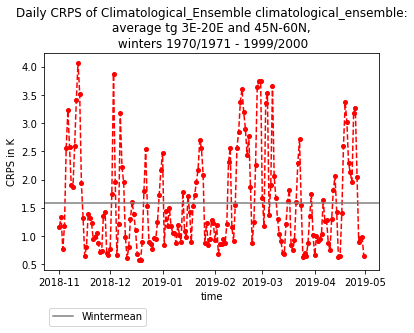

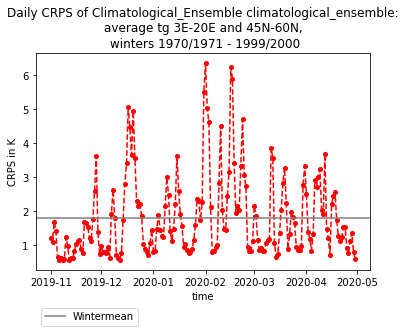

In [20]:
# The CRPS values for each winter are plotted separately. In combination with the plot above a first plausibility
# check is possible. The lower the CRPS value, the more similar the prediction of the climatological 
# ensemble and the ground truth have to be.
for m in range(len(start_years_of_winter)):
    fig = plt.subplots()
    plt.plot(forecast_dates[m], crps_winterwise[m], color='r', marker='o', markersize=4, linestyle='--')
    plt.axhline(y=np.nanmean(crps_winterwise[m]), color='grey', linestyle='-', label='Wintermean')
    plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left')
    plt.xlabel(time_column_name_ground_truth)
    plt.ylabel('CRPS in '+config['unit_of_ground_truth_and_climatological_ensemble'])
    plt.title('Daily CRPS of '+config['model_name']+' climatological_ensemble:\n '+str_input_info_for_plot_titles)
    plt.savefig(config['PATH_plots']+config['model_name']+'_CRPS_'+config['ground_truth']+'_'+config['location_ground_truth']+'_input_'+config['input_data']+'_'+config['location_input']+'_'+str(start_years_of_winter[m])+'_'+str(start_years_of_winter[m]+1)+'.png', bbox_inches='tight')

#### Visualizing the CRPS for all winters in the evaluation period for a quick overview of the forecasting performance of the climatological ensemble

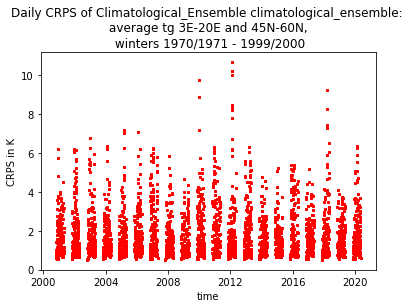

In [21]:
# The timeseries of the daily CRPS values is plotted for the whole evaluation period.
plt.plot(forecast_time, crps, marker='s', linestyle='', markersize=2, color='r')
plt.xlabel(time_column_name_ground_truth)
plt.ylabel('CRPS in '+config['unit_of_ground_truth_and_climatological_ensemble'])
plt.title('Daily CRPS of '+config['model_name']+' climatological_ensemble: \n '+str_input_info_for_plot_titles)
plt.savefig(config['PATH_plots']+config['model_name']+'_CRPS_'+config['ground_truth']+'_'+config['location_ground_truth']+'_input_'+config['input_data']+'_'+config['location_input']+'_'+str(config['start_year_of_first_winter'])+'_'+str(config['start_year_of_last_winter']+1)+'.png', bbox_inches='tight')

In [22]:
# End of Program